<a href="https://colab.research.google.com/github/jhenningsen/Equity_Analysis/blob/main/Leverage_ETFs/Log_Mean_Reversion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TQQQ Trading Strategy Backtesting with Logarithmic Trend Mean Reversion

This notebook develops and backtests a systematic trading strategy for TQQQ (ProShares UltraPro QQQ 3x Leveraged ETF) using a logarithmic trend mean reversion approach. The backtest period runs from TQQQ's inception date (February 11, 2010) to the present, utilizing adjusted prices from `yfinance`.

## Project Goals:
1.  **Develop a Mean Reversion Strategy:** Implement a strategy that profits from TQQQ's tendency to revert to its long-term logarithmic trend.
2.  **Compare Performance:** Evaluate the strategy against a TQQQ Buy and Hold benchmark using key metrics like CAGR, Max Drawdown, and visual equity curves.

## Strategy: Mean Reversion Strategy based on Logarithmic Trend
*   **Core Concept:** This strategy aims to profit from the tendency of TQQQ's price to revert to its long-term logarithmic trend. It identifies overbought and oversold conditions based on residuals from a linear regression of TQQQ's log price over time.
*   **Mechanics:** Uses Gaussian Mixture Models (GMM) to cluster the residuals into different regimes (e.g., most oversold, moderately oversold, moderately overbought, most overbought). Allocations to TQQQ are then dynamically adjusted based on these residual regimes, with higher allocations when TQQQ is oversold and lower/zero allocations when overbought.

## Benchmark: TQQQ Buy and Hold
*   **Core Concept:** A pure, passive buy-and-hold baseline to evaluate strategy outperformance (Alpha) and risk-adjusted return profiles.
*   **Mechanics:** Fully vectorized execution. 100% of capital is deployed into TQQQ on day one, compounding daily based on TQQQ's fractional percent changes.
*   **Historical Performance:** Historically (2010–2026), this benchmark compounds at a ~40% to 44% CAGR, but suffers an extreme maximum drawdown of ~81.6% during the 2022 market regime shift.

In [68]:
# Import necessary libraries

import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display # Ensure display is available
from ipywidgets import interact, FloatSlider



In [69]:
# Clear all DataFrames from memory
import gc

# Get a list of all variables in the global namespace
all_vars = list(globals().keys())

# Identify and delete pandas DataFrames
for var_name in all_vars:
    if isinstance(globals()[var_name], pd.DataFrame):
        del globals()[var_name]
        print(f"Deleted DataFrame: {var_name}")

# Run garbage collector to free up memory
gc.collect()

print("All DataFrames cleared from memory.")

Deleted DataFrame: tqqq_data
Deleted DataFrame: regression_df
Deleted DataFrame: X
Deleted DataFrame: residual_summary
Deleted DataFrame: strategy_df
Deleted DataFrame: regression_df_continuous_strategy
Deleted DataFrame: strategy_df_continuous
Deleted DataFrame: temp_regression_df_continuous_strategy
Deleted DataFrame: temp_strategy_df_continuous
Deleted DataFrame: results_df
All DataFrames cleared from memory.


In [70]:
# Download TQQQ data
tickers = ["TQQQ"]
tqqq_data = yf.download(tickers, start="2010-02-11", end="2026-01-01", auto_adjust=True)['Close'].dropna()

# Convert to DataFrame if it's a Series (ensure tqqq_data is a DataFrame for subsequent operations)
if isinstance(tqqq_data, pd.Series):
    tqqq_data = tqqq_data.to_frame(name='TQQQ')

# Calculate TQQQ returns and create benchmark equity
tqqq_data['TQQQ_Return'] = tqqq_data['TQQQ'].pct_change()

# Create a copy for regression analysis and to serve as the consistent base for all strategies
regression_df = tqqq_data.copy()

# Calculate Standard_Benchmark_Equity once here to be used across all strategies
initial_portfolio_value_benchmark = 100000.0
# Use fillna(1) for the first return to correctly initialize cumprod for the benchmark
regression_df['Standard_Benchmark_Equity'] = (1 + regression_df['TQQQ_Return']).fillna(1).cumprod() * initial_portfolio_value_benchmark

print("\nTQQQ data and Benchmark Equity prepared.")

[*********************100%***********************]  1 of 1 completed


TQQQ data and Benchmark Equity prepared.


## Mean Reversion Strategy based on Logarithmic Trend

In [71]:
# Calculate TQQQ log price, trend line, and residuals
# These calculations are moved here to precede the plotting in cell 3e99eace

regression_df['TQQQ_Log_Price'] = np.log(regression_df['TQQQ'])
regression_df['Days_Since_Start'] = np.arange(len(regression_df))
X = regression_df[['Days_Since_Start']]
y = regression_df['TQQQ_Log_Price']
model = LinearRegression()
model.fit(X, y)
regression_df['TQQQ_Trend_Line'] = model.predict(X)
regression_df['TQQQ_Residuals'] = regression_df['TQQQ_Log_Price'] - regression_df['TQQQ_Trend_Line']

print("TQQQ Log Price, Trend Line, and Residuals calculated and added to regression_df.")

# Discover residual regimes using GMM and define allocations (moved from cell 4e80d8e8)
X_residuals = regression_df['TQQQ_Residuals'].values.reshape(-1, 1)
gmm_residuals = GaussianMixture(n_components=4, random_state=42, covariance_type='full')
raw_labels_residuals = gmm_residuals.fit_predict(X_residuals)
idx_residuals = np.argsort(gmm_residuals.means_.flatten())
state_map_residuals = {old_label: new_label for new_label, old_label in enumerate(idx_residuals)}
regression_df['Residual_Regime'] = [state_map_residuals[label] for label in raw_labels_residuals]

# Generate and display the summary of discovered residual regimes
print("\n--- DISCOVERED RESIDUAL REGIMES ---")
residual_summary = regression_df.groupby('Residual_Regime')['TQQQ_Residuals'].agg(['min', 'max', 'mean', 'count'])
display(residual_summary)


TQQQ Log Price, Trend Line, and Residuals calculated and added to regression_df.

--- DISCOVERED RESIDUAL REGIMES ---


,min,max,mean,count
Residual_Regime,,,,
0,-1.063691,-0.453206,-0.655360,316
1,-0.451638,0.024853,-0.179508,1941
2,0.025514,0.455915,0.213830,1346
3,0.456365,1.008558,0.679451,394


In [72]:
# Calculate the overall mean residual from the TQQQ_Residuals column
mean_residual_overall = regression_df['TQQQ_Residuals'].mean()
print(f"Overall Mean Residual: {mean_residual_overall:.3f}")

Overall Mean Residual: -0.000


Now, let's visualize the log price, the linear regression trend line, and the residuals. This will help us understand the deviations from the trend.

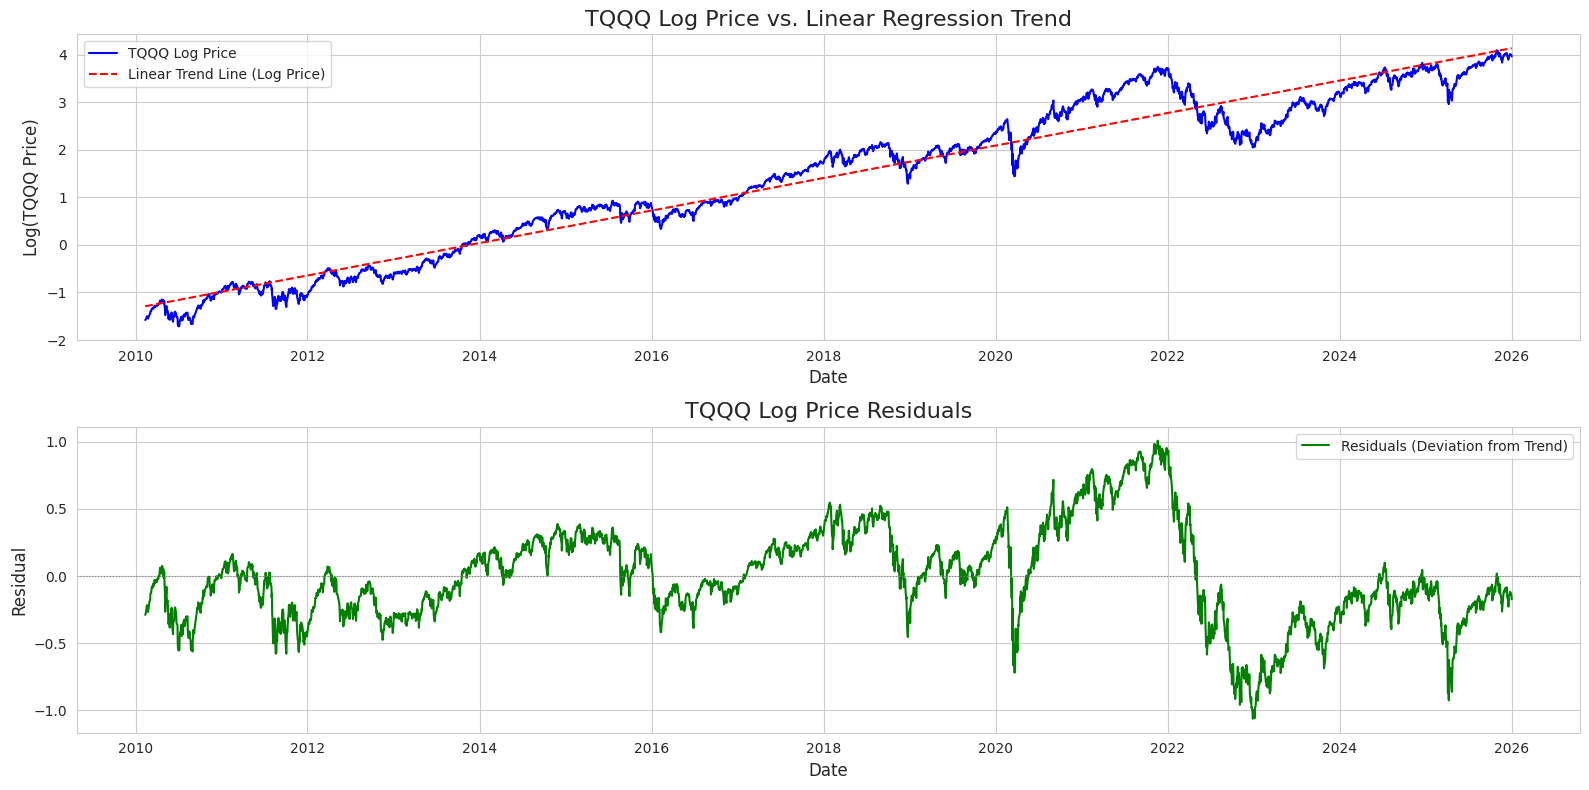

In [73]:
# Plot TQQQ log price, trend, and residuals
plt.figure(figsize=(16, 8))

# Plot Log Price and Trend Line
plt.subplot(2, 1, 1) # 2 rows, 1 column, first plot
plt.plot(regression_df.index, regression_df['TQQQ_Log_Price'], label='TQQQ Log Price', color='blue')
plt.plot(regression_df.index, regression_df['TQQQ_Trend_Line'], label='Linear Trend Line (Log Price)', color='red', linestyle='--')
plt.title('TQQQ Log Price vs. Linear Regression Trend', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Log(TQQQ Price)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)

# Plot Residuals
plt.subplot(2, 1, 2) # 2 rows, 1 column, second plot
plt.plot(regression_df.index, regression_df['TQQQ_Residuals'], label='Residuals (Deviation from Trend)', color='green')
plt.axhline(0, color='gray', linestyle=':', linewidth=0.8)
plt.title('TQQQ Log Price Residuals', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Residual', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)

plt.tight_layout()
plt.show()

The residuals represent how far TQQQ's log price is from its calculated long-term linear trend. A mean reversion strategy would typically involve:

1.  **Going Long (Buying TQQQ):** When the residuals fall significantly below zero, indicating TQQQ is oversold relative to its trend.
2.  **Going Short (Selling TQQQ):** When the residuals rise significantly above zero, indicating TQQQ is overbought relative to its trend.

You would need to define thresholds (e.g., standard deviations of residuals) to trigger these buy/sell signals.

## Mean Reversion Strategy Implementation

### Backtesting the Discrete Residual Mean Reversion Strategy

In [74]:
# --- Start of consolidated logic to prepare regression_df and create strategy_df ---

# (From b0ef9d33) Calculate TQQQ log price, trend line, and residuals
# These calculations are now handled in cell 1da11918, so this block can be removed or kept as a safeguard
# if 'TQQQ_Log_Price' not in regression_df.columns:
#     regression_df['TQQQ_Log_Price'] = np.log(regression_df['TQQQ'])
#     regression_df['Days_Since_Start'] = np.arange(len(regression_df))
#     X = regression_df[['Days_Since_Start']]
#     y = regression_df['TQQQ_Log_Price']
#     model = LinearRegression()
#     model.fit(X, y)
#     regression_df['TQQQ_Trend_Line'] = model.predict(X)
#     regression_df['TQQQ_Residuals'] = regression_df['TQQQ_Log_Price'] - regression_df['TQQQ_Trend_Line']

# (From f00c774e) Discover residual regimes using GMM and define allocations
# This part has been moved to cell 1da11918. Only the allocation_map definition remains here.
if 'Target_Allocation' not in regression_df.columns:
    # Ensure Residual_Regime is calculated (it should be from cell 1da11918)
    if 'Residual_Regime' not in regression_df.columns:
        print("Warning: 'Residual_Regime' not found. Please ensure cell 1da11918 is executed.")
        # Fallback if 1da11918 was not run, re-run GMM logic here (optional, for robustness)
        X_residuals = regression_df['TQQQ_Residuals'].values.reshape(-1, 1)
        gmm_residuals = GaussianMixture(n_components=4, random_state=42, covariance_type='full')
        raw_labels_residuals = gmm_residuals.fit_predict(X_residuals)
        idx_residuals = np.argsort(gmm_residuals.means_.flatten())
        state_map_residuals = {old_label: new_label for new_label, old_label in enumerate(idx_residuals)}
        regression_df['Residual_Regime'] = [state_map_residuals[label] for label in raw_labels_residuals]

    allocation_map = {
        0: 1.0,  # Most oversold: 100% TQQQ
        1: 0.75, # Moderately oversold: 75% TQQQ
        2: 0.25, # Moderately overbought: 25% TQQQ
        3: 0.0   # Most overbought: 0% TQQQ (cash)
    }
    regression_df['Target_Allocation'] = regression_df['Residual_Regime'].map(allocation_map)

# (From 50d6af2c) Backtest Residual Mean Reversion Strategy and create strategy_df
# Only create strategy_df if it doesn't already exist in the current session
if 'strategy_df' not in locals() or strategy_df is None:
    strategy_df = regression_df[['TQQQ', 'TQQQ_Return', 'Target_Allocation']].copy()
    strategy_df['TQQQ_Daily_Return'] = strategy_df['TQQQ_Return']
    strategy_df = strategy_df.dropna()
    strategy_df['Allocated_Weight'] = strategy_df['Target_Allocation'].shift(1)
    strategy_df = strategy_df.dropna()
    strategy_df['Strategy_Daily_Return'] = strategy_df['Allocated_Weight'] * strategy_df['TQQQ_Daily_Return']
    initial_portfolio_value = 100000.0
    strategy_df['Strategy_Equity'] = (1 + strategy_df['Strategy_Daily_Return']).cumprod() * initial_portfolio_value
    strategy_df['Benchmark_Equity'] = regression_df['Standard_Benchmark_Equity'].reindex(strategy_df.index)

# --- End of consolidated logic ---

# Performance Metrics Calculation
# (Using the same calculate_metrics function from earlier, if defined. If not, redefining it here for robustness.)
def calculate_metrics(return_series, equity_series, initial_value):
    if len(equity_series) == 0 or initial_value == 0:
        return 0.0, 0.0, 0.0, 0.0

    total_return = (equity_series.iloc[-1] / initial_value - 1)
    # Ensure we have enough data points for annualization
    if len(equity_series) < 252:
        years = len(equity_series) / 252.0 if len(equity_series) > 0 else 1.0
    else:
        years = (equity_series.index[-1] - equity_series.index[0]).days / 365.25

    cagr = ((equity_series.iloc[-1] / initial_value) ** (1 / years) - 1) * 100 if years > 0 else 0.0
    ann_vol = return_series.std() * np.sqrt(252) * 100
    sharpe = cagr / ann_vol if ann_vol != 0 else 0.0

    rolling_max = equity_series.cummax()
    drawdowns = (equity_series - rolling_max) / rolling_max
    max_dd = drawdowns.min() * 100
    return cagr, ann_vol, sharpe, max_dd

strat_cagr, strat_vol, strat_sharpe, strat_mdd = calculate_metrics(
    strategy_df['Strategy_Daily_Return'], strategy_df['Strategy_Equity'], initial_portfolio_value)
bench_cagr, bench_vol, bench_sharpe, bench_mdd = calculate_metrics(
    strategy_df['TQQQ_Daily_Return'], strategy_df['Benchmark_Equity'], initial_portfolio_value)

final_strat_equity = strategy_df['Strategy_Equity'].iloc[-1]
final_bench_equity = strategy_df['Benchmark_Equity'].iloc[-1]

val_strat_str = f"${final_strat_equity:,.2f}"
val_bench_str = f"${final_bench_equity:,.2f}"
cagr_strat_str = f"{strat_cagr:.2f}%"
cagr_bench_str = f"{bench_cagr:.2f}%"
mdd_strat_str = f"{strat_mdd:.2f}%"
mdd_bench_str = f"{bench_mdd:.2f}%"

print(f"\n{'Metric':<25}{'Residual Mean Reversion':<25}{'TQQQ Buy & Hold':<20}")
print("-" * 70)
print(f"{'Ending Portfolio Value':<25}{val_strat_str:<25}{val_bench_str:<20}")
print(f"{'CAGR':<25}{cagr_strat_str:<25}{cagr_bench_str:<20}")
print(f"{'Annualized Vol':<25}{f'{strat_vol:.2f}%':<25}{f'{bench_vol:.2f}%':<20}")
print(f"{'Sharpe Ratio':<25}{f'{strat_sharpe:.2f}':<25}{f'{bench_sharpe:.2f}':<20}")
print(f"{'Max Drawdown':<25}{mdd_strat_str:<25}{mdd_bench_str:<20}")
print("-" * 70)


Metric                   Residual Mean Reversion  TQQQ Buy & Hold     
----------------------------------------------------------------------
Ending Portfolio Value   $27,314,190.00           $25,543,131.84      
CAGR                     42.40%                   41.80%              
Annualized Vol           41.75%                   61.11%              
Sharpe Ratio             1.02                     0.68                
Max Drawdown             -53.01%                  -81.66%             
----------------------------------------------------------------------


### Residual Mean Reversion Strategy Equity Curve

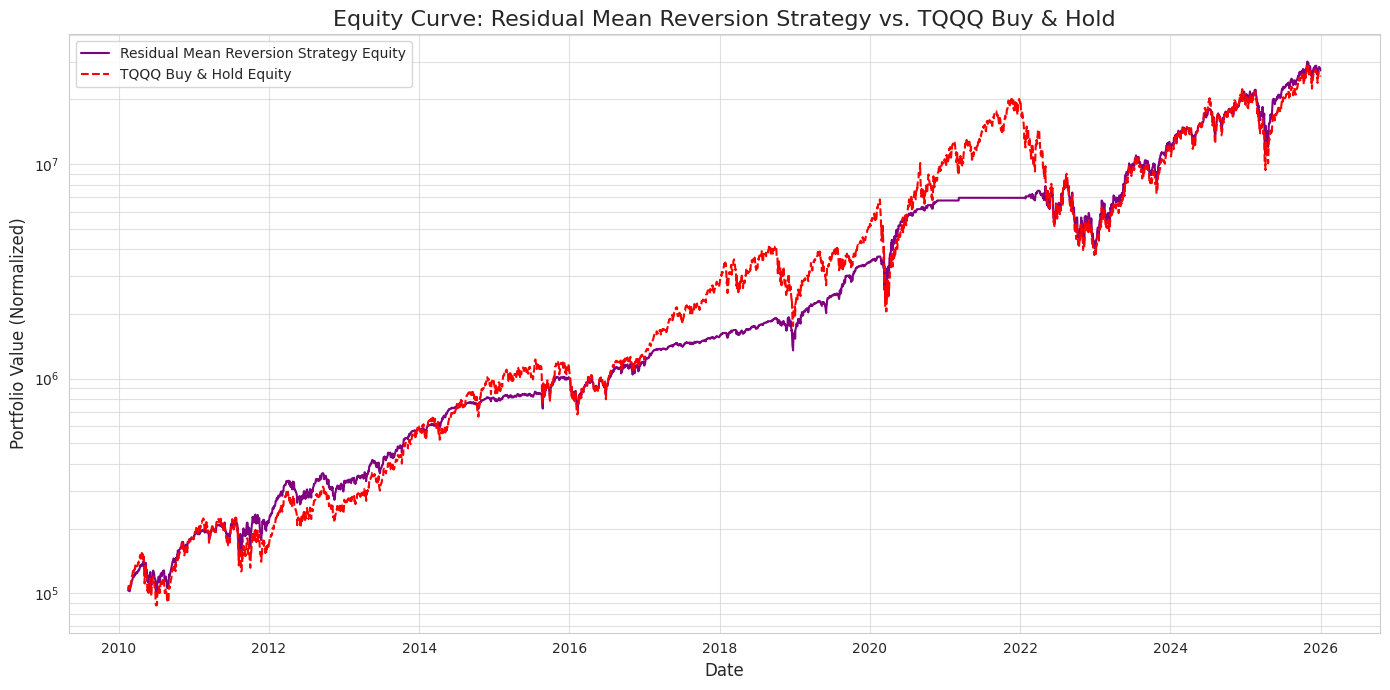

In [75]:
# Plot equity curve for Residual Mean Reversion Strategy
sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))

plt.plot(strategy_df.index, strategy_df['Strategy_Equity'], label='Residual Mean Reversion Strategy Equity', color='purple')
plt.plot(strategy_df.index, strategy_df['Benchmark_Equity'], label='TQQQ Buy & Hold Equity', color='red', linestyle='--')

plt.title('Equity Curve: Residual Mean Reversion Strategy vs. TQQQ Buy & Hold', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value (Normalized)', fontsize=12)
plt.legend(fontsize=10)
plt.yscale('log') # Use log scale for better visualization of exponential growth
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

## Continuous Residual Allocation Strategy (Weekly Basis)

This strategy refines the mean reversion approach by implementing a more *gradual* capital allocation based on TQQQ's residuals, updated on a weekly basis. Instead of discrete switches between allocation percentages when residual regimes are crossed, this strategy uses a sigmoid function to continuously map residual values to allocation percentages (between 0% and 100% TQQQ).

**Mechanics:**
*   **Weekly Residual Signal:** The strategy re-samples the daily TQQQ residuals to a weekly frequency, taking the last residual value of each week as the signal.
*   **Sigmoid Allocation:** A sigmoid function is applied to the weekly residual signal. This function is configured such that:
    *   Very negative residuals (oversold) result in high TQQQ allocation (approaching 100%).
    *   Very positive residuals (overbought) result in low TQQQ allocation (approaching 0%).
    *   Residuals near zero result in moderate TQQQ allocation.
*   **Forward-Filled Daily Allocation:** The weekly allocation is then forward-filled to all trading days within that week, and a 1-day lag is applied to avoid look-ahead bias.
*   **Backtest:** The strategy is backtested against the TQQQ Buy & Hold benchmark using the same performance metrics.

Continuous weekly allocations calculated.
Continuous Residual Allocation Strategy backtest complete.

Metric                   Continuous Residual StratTQQQ Buy & Hold     
----------------------------------------------------------------------
Ending Portfolio Value   $22,354,365.54           $25,543,131.84      
CAGR                     40.61%                   41.80%              
Annualized Vol           38.96%                   61.11%              
Sharpe Ratio             1.04                     0.68                
Max Drawdown             -50.83%                  -81.66%             
----------------------------------------------------------------------


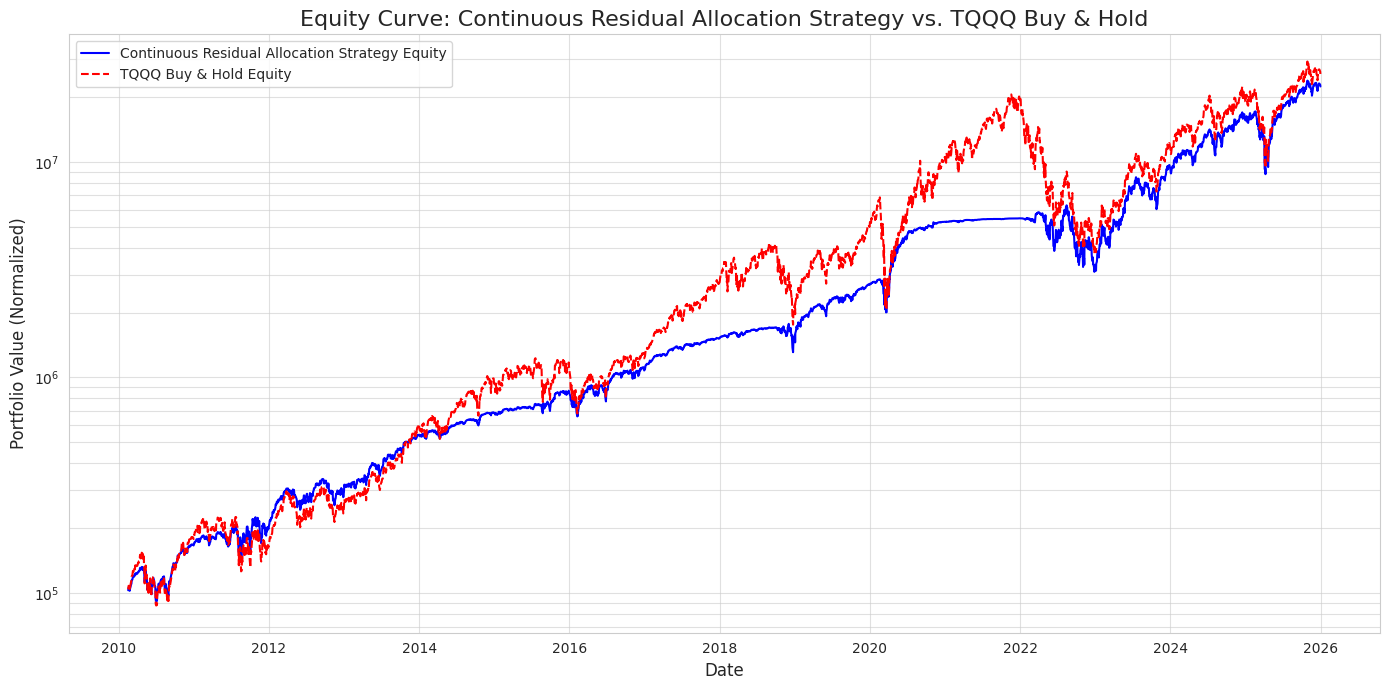

In [76]:
# --- Implement and Backtest Continuous Residual Allocation Strategy ---

# Make a copy of regression_df for this new strategy
regression_df_continuous_strategy = regression_df.copy()

# 1. Resample residuals to weekly frequency, indexed by the *end* of the week (Sunday)
# We'll use the last residual value of the week to determine the allocation for the *next* week.
weekly_residuals_signal = regression_df_continuous_strategy['TQQQ_Residuals'].resample('W').last()

# 2. Define sigmoid parameters and calculate continuous allocations for these weekly signals
k_factor = 5 # Controls the steepness of the sigmoid curve; higher k_factor means more sensitive to residuals

# Apply sigmoid function: high residuals -> low allocation, low residuals -> high allocation
weekly_allocations_calculated = 1 / (1 + np.exp(k_factor * (weekly_residuals_signal - mean_residual_overall)))
weekly_allocations_calculated.name = 'Target_Allocation_Continuous'

# 3. Reindex weekly allocations to the daily DataFrame's index and fill NaNs
# This will align the weekly allocations with the daily dates.
# 'ffill' will propagate the *previous* week's allocation until a new one is available.
daily_target_allocations = weekly_allocations_calculated.reindex(regression_df_continuous_strategy.index, method='ffill')

# 'bfill' to handle any NaNs at the very beginning if the first weekly signal is after the first daily date
daily_target_allocations.bfill(inplace=True);

# Assign the fully populated daily target allocations
regression_df_continuous_strategy['Target_Allocation_Continuous'] = daily_target_allocations

print("Continuous weekly allocations calculated.")

# 4. Backtest the new strategy
# (Redefining calculate_metrics function for self-containment if not globally available)
def calculate_metrics(return_series, equity_series, initial_value):
    if len(equity_series) == 0 or initial_value == 0:
        return 0.0, 0.0, 0.0, 0.0, 0.0

    total_return = (equity_series.iloc[-1] / initial_value - 1)
    if len(equity_series) < 252:
        years = len(equity_series) / 252.0 if len(equity_series) > 0 else 1.0
    else:
        years = (equity_series.index[-1] - equity_series.index[0]).days / 365.25

    cagr = ((equity_series.iloc[-1] / initial_value) ** (1 / years) - 1) * 100 if years > 0 else 0.0
    ann_vol = return_series.std() * np.sqrt(252) * 100
    sharpe = cagr / ann_vol if ann_vol != 0 else 0.0

    rolling_max = equity_series.cummax()
    drawdowns = (equity_series - rolling_max) / rolling_max
    max_dd = drawdowns.min() * 100
    final_equity = equity_series.iloc[-1]
    return cagr, ann_vol, sharpe, max_dd, final_equity

# Create strategy_df for continuous allocation
strategy_df_continuous = regression_df_continuous_strategy[['TQQQ', 'TQQQ_Return', 'Target_Allocation_Continuous']].copy()
strategy_df_continuous['TQQQ_Daily_Return'] = strategy_df_continuous['TQQQ_Return']
strategy_df_continuous = strategy_df_continuous.dropna()

# Apply 1-day lag to allocation to prevent look-ahead bias
strategy_df_continuous['Allocated_Weight'] = strategy_df_continuous['Target_Allocation_Continuous'].shift(1)
strategy_df_continuous = strategy_df_continuous.dropna()

strategy_df_continuous['Strategy_Daily_Return'] = strategy_df_continuous['Allocated_Weight'] * strategy_df_continuous['TQQQ_Daily_Return']

initial_portfolio_value = 100000.0
strategy_df_continuous['Strategy_Equity'] = (1 + strategy_df_continuous['Strategy_Daily_Return']).cumprod() * initial_portfolio_value
strategy_df_continuous['Benchmark_Equity'] = regression_df_continuous_strategy['Standard_Benchmark_Equity'].reindex(strategy_df_continuous.index)

print("Continuous Residual Allocation Strategy backtest complete.")

# 5. Calculate and display performance metrics
strat_cont_cagr, strat_cont_vol, strat_cont_sharpe, strat_cont_mdd, final_strat_cont_equity = calculate_metrics(
    strategy_df_continuous['Strategy_Daily_Return'], strategy_df_continuous['Strategy_Equity'], initial_portfolio_value)
bench_cagr, bench_vol, bench_sharpe, bench_mdd, final_bench_equity_cont = calculate_metrics(
    strategy_df_continuous['TQQQ_Daily_Return'], strategy_df_continuous['Benchmark_Equity'], initial_portfolio_value)

val_strat_cont_str = f"${final_strat_cont_equity:,.2f}"
val_bench_cont_str = f"${final_bench_equity_cont:,.2f}"
cagr_strat_cont_str = f"{strat_cont_cagr:.2f}%"
cagr_bench_cont_str = f"{bench_cagr:.2f}%"
mdd_strat_cont_str = f"{strat_cont_mdd:.2f}%"
mdd_bench_cont_str = f"{bench_mdd:.2f}%"

print(f"\n{'Metric':<25}{'Continuous Residual Strat':<25}{'TQQQ Buy & Hold':<20}")
print("-" * 70)
print(f"{'Ending Portfolio Value':<25}{val_strat_cont_str:<25}{val_bench_cont_str:<20}")
print(f"{'CAGR':<25}{cagr_strat_cont_str:<25}{cagr_bench_cont_str:<20}")
print(f"{'Annualized Vol':<25}{f'{strat_cont_vol:.2f}%':<25}{f'{bench_vol:.2f}%':<20}")
print(f"{'Sharpe Ratio':<25}{f'{strat_cont_sharpe:.2f}':<25}{f'{bench_sharpe:.2f}':<20}")
print(f"{'Max Drawdown':<25}{mdd_strat_cont_str:<25}{mdd_bench_cont_str:<20}")
print("-" * 70)

# 6. Plot equity curve
sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))

plt.plot(strategy_df_continuous.index, strategy_df_continuous['Strategy_Equity'], label='Continuous Residual Allocation Strategy Equity', color='blue')
plt.plot(strategy_df_continuous.index, strategy_df_continuous['Benchmark_Equity'], label='TQQQ Buy & Hold Equity', color='red', linestyle='--')

plt.title('Equity Curve: Continuous Residual Allocation Strategy vs. TQQQ Buy & Hold', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value (Normalized)', fontsize=12)
plt.legend(fontsize=10)
plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

## Analysis of Minimum Residual Allocation Values

This section explores how setting a minimum allocation threshold (between 0.5 and 1.0) affects the continuous residual allocation strategy's performance. A higher minimum allocation means the strategy will always invest at least that percentage in TQQQ, even if residuals suggest a lower allocation. This analysis helps determine the impact of such a floor on CAGR, Sharpe Ratio, and Maximum Drawdown.

In [77]:
# Define the range of minimum allocation values to test
min_allocation_values = np.linspace(0.0, 1.0, 11) # e.g., 0.5, 0.6, 0.7, 0.8, 0.9, 1.0

results = []
initial_portfolio_value = 100000.0 # Ensure this is consistent
k_factor = 5 # Use the default k_factor from the strategy

print("Analyzing Continuous Strategy with varying Minimum Allocation levels...")

for min_alloc in min_allocation_values:
    # Create a temporary copy to avoid modifying the global regression_df
    temp_regression_df_continuous_strategy = regression_df.copy()

    # 1. Resample residuals to weekly frequency
    temp_weekly_residuals_signal = temp_regression_df_continuous_strategy['TQQQ_Residuals'].resample('W').last()

    # 2. Calculate continuous allocations with the sigmoid function
    temp_weekly_allocations_unadjusted = 1 / (1 + np.exp(k_factor * (temp_weekly_residuals_signal - mean_residual_overall)))

    # Apply the minimum allocation floor
    temp_weekly_allocations_calculated = temp_weekly_allocations_unadjusted.apply(lambda x: max(x, min_alloc))
    temp_weekly_allocations_calculated.name = 'Target_Allocation_Continuous'

    # 3. Reindex weekly allocations to daily DataFrame's index and fill NaNs
    temp_daily_target_allocations = temp_weekly_allocations_calculated.reindex(
        temp_regression_df_continuous_strategy.index, method='ffill')
    temp_daily_target_allocations.bfill(inplace=True)

    temp_regression_df_continuous_strategy['Target_Allocation_Continuous'] = temp_daily_target_allocations

    # 4. Backtest the new strategy
    temp_strategy_df_continuous = temp_regression_df_continuous_strategy[['TQQQ', 'TQQQ_Return', 'Target_Allocation_Continuous']].copy()
    temp_strategy_df_continuous['TQQQ_Daily_Return'] = temp_strategy_df_continuous['TQQQ_Return']
    temp_strategy_df_continuous = temp_strategy_df_continuous.dropna()

    temp_strategy_df_continuous['Allocated_Weight'] = temp_strategy_df_continuous['Target_Allocation_Continuous'].shift(1)
    temp_strategy_df_continuous = temp_strategy_df_continuous.dropna()

    temp_strategy_df_continuous['Strategy_Daily_Return'] = temp_strategy_df_continuous['Allocated_Weight'] * temp_strategy_df_continuous['TQQQ_Daily_Return']

    temp_strategy_df_continuous['Strategy_Equity'] = (1 + temp_strategy_df_continuous['Strategy_Daily_Return']).cumprod() * initial_portfolio_value

    # Calculate metrics using the globally defined calculate_metrics function from cell 7e367642
    cagr, ann_vol, sharpe, max_dd, final_equity = calculate_metrics(
        temp_strategy_df_continuous['Strategy_Daily_Return'], temp_strategy_df_continuous['Strategy_Equity'], initial_portfolio_value)

    results.append({
        'Min Allocation': f"{min_alloc:.2f}",
        'Ending Portfolio Value': f"${final_equity:,.2f}",
        'CAGR (%)': f"{cagr:.2f}",
        'Annualized Vol (%)': f"{ann_vol:.2f}",
        'Sharpe Ratio': f"{sharpe:.2f}",
        'Max Drawdown (%)': f"{max_dd:.2f}"
    })

# Display results
results_df = pd.DataFrame(results)
print("\nPerformance with Different Minimum Allocation Values:")
display(results_df)

Analyzing Continuous Strategy with varying Minimum Allocation levels...

Performance with Different Minimum Allocation Values:


,Min Allocation,Ending Portfolio Value,CAGR (%),Annualized Vol (%),Sharpe Ratio,Max Drawdown (%)
0,0.00,"$22,354,365.54",40.61,38.96,1.04,-50.83
1,0.10,"$21,931,865.74",40.44,39.00,1.04,-50.83
2,0.20,"$21,061,336.06",40.09,39.22,1.02,-50.83
3,0.30,"$21,053,336.08",40.08,39.77,1.01,-53.87
4,0.40,"$21,802,084.72",40.39,40.69,0.99,-57.06
5,0.50,"$22,045,696.92",40.49,42.30,0.96,-60.45
6,0.60,"$22,455,331.77",40.65,44.52,0.91,-64.25
7,0.70,"$21,652,167.70",40.33,47.44,0.85,-68.56
8,0.80,"$21,007,045.11",40.06,51.13,0.78,-73.47
9,0.90,"$21,503,017.15",40.27,55.68,0.72,-77.91


## Visualizing Residual Value vs. Allocation (Interactive `k_factor`)

This section provides an interactive visualization to understand how TQQQ residual values are mapped to a continuous allocation percentage (between 0% and 100% TQQQ) using a sigmoid function. You can adjust the `k_factor` to see its effect on the curve's steepness, which directly influences how sensitive the allocation is to changes in residuals.

In [78]:
# Get the overall mean residual from regression_df (already calculated earlier)

def plot_allocation_curve(k_factor_interactive):
    # Generate a range of residual values for plotting the curve
    residual_range = np.linspace(regression_df_continuous_strategy['TQQQ_Residuals'].min() - 0.1,
                               regression_df_continuous_strategy['TQQQ_Residuals'].max() + 0.1, 500)

    # Calculate allocations using the sigmoid function for the residual range
    allocations_for_plot = 1 / (1 + np.exp(k_factor_interactive * (residual_range - mean_residual_overall)))

    plt.figure(figsize=(10, 6))
    plt.plot(residual_range, allocations_for_plot, color='blue', linewidth=2, label=f'Allocation Curve (k_factor={k_factor_interactive:.1f})')

    # Plot actual weekly residual signals and their calculated allocations
    # Use the 'weekly_residuals_signal' and 'weekly_allocations_calculated' from the previous cell
    plt.scatter(weekly_residuals_signal, weekly_allocations_calculated,
                alpha=0.6, color='red', s=10, label='Actual Weekly Residuals & Allocations')

    plt.axvline(mean_residual_overall, color='gray', linestyle='--', label=f'Mean Residual ({mean_residual_overall:.3f})')
    plt.axhline(0.5, color='green', linestyle=':', label='50% Allocation')

    plt.title('Residual Value vs. TQQQ Allocation', fontsize=16)
    plt.xlabel('TQQQ Residual Value (Log Price Deviation)', fontsize=12)
    plt.ylabel('Target TQQQ Allocation (0 to 1)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=10)
    plt.ylim(-0.05, 1.05) # Ensure full range of allocation is visible
    plt.tight_layout()
    plt.show()

# Create an interactive slider for k_factor
k_factor_slider = FloatSlider(min=1.0, max=20.0, step=0.5, value=k_factor, description='k_factor:')

# Display the interactive plot
interact(plot_allocation_curve, k_factor_interactive=k_factor_slider);

interactive(children=(FloatSlider(value=5.0, description='k_factor:', max=20.0, min=1.0, step=0.5), Output()),…